In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [4]:
titanic = pd.read_csv("/content/train.csv")

In [5]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
embarked_dummies = pd.get_dummies(titanic['Embarked'], prefix='Embarked').astype(int)
titanic = pd.concat([titanic, embarked_dummies], axis=1)

In [7]:
# Drop unused columns
titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis=1, inplace=True)

# Fill missing values
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)

# Encode 'Sex'
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1}).astype(int)

In [8]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [9]:
# Features and target
X = titanic.drop('Survived', axis=1)
y = titanic['Survived']

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
for n_components in [3, 5, 7, 9]:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

In [11]:
# Create PCA DataFrame
pca_columns = [f'PCA_{i+1}' for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)

In [12]:
# Add PCA features to original DataFrame
X = pd.concat([X.reset_index(drop=True), pca_df], axis=1)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
model = LogisticRegression()


In [16]:
scores = cross_val_score(model, X, y, cv=4) # K = 4
scores

array([0.78475336, 0.79820628, 0.77130045, 0.81081081])

In [17]:
model.fit(X_train, y_train)


LogisticRegression()

In [18]:
y_pred = pd.Series(model.predict(X_test))


In [19]:
from sklearn import metrics # Import the metrics module from sklearn

y_test = y_test.reset_index(drop=True)
z = pd.concat([y_test, y_pred], axis=1)
z.columns = ['True', 'Prediction']
acc_log = metrics.accuracy_score(y_test, y_pred)
pre_log = metrics.precision_score(y_test, y_pred)
rec_log = metrics.recall_score(y_test, y_pred)
f1_log = f1_score(y_test, y_pred, average='micro')
cohen_log = cohen_kappa_score(y_test, y_pred)


In [20]:

z.head()


,True,Prediction
0,1,0
1,0,0
2,0,0
3,1,1
4,1,1


In [21]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432


Text(0.5, 23.52222222222222, 'Predicted')

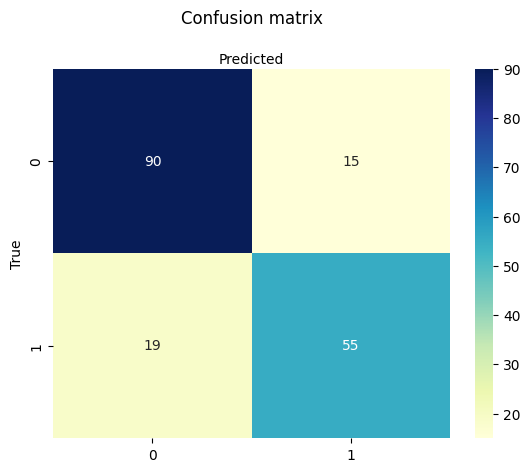

In [22]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [23]:
from sklearn.neighbors import KNeighborsClassifier


In [24]:
knn = KNeighborsClassifier(n_neighbors = 3)


In [25]:
scores = cross_val_score(knn, X, y, cv=4) # K = 4
scores

array([0.66816143, 0.73542601, 0.68161435, 0.70720721])

In [26]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

acc_knn = metrics.accuracy_score(y_test, y_pred)
pre_knn = metrics.precision_score(y_test, y_pred)
rec_knn = metrics.recall_score(y_test, y_pred)
f1_knn = f1_score(y_test, y_pred, average='micro')
cohen_knn = cohen_kappa_score(y_test, y_pred)


In [27]:

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.7597765363128491
Precision: 0.7818181818181819
Recall: 0.581081081081081


Text(0.5, 23.52222222222222, 'Predicted')

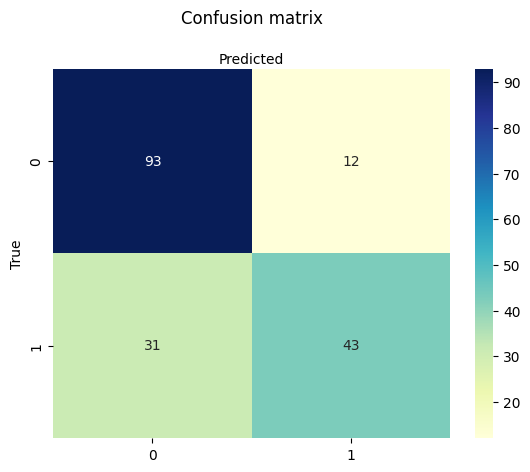

In [28]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [29]:
from sklearn.svm import SVC, LinearSVC


In [30]:
linear_svc = LinearSVC()

In [31]:

scores = cross_val_score(linear_svc, X, y, cv=4) # K = 4
scores

array([0.78923767, 0.81165919, 0.76681614, 0.8018018 ])

In [32]:
linear_svc.fit(X_train, y_train)

y_pred = linear_svc.predict(X_test)

acc_linear_svc = metrics.accuracy_score(y_test, y_pred)
pre_linear_svc = metrics.precision_score(y_test, y_pred)
rec_linear_svc = metrics.recall_score(y_test, y_pred)
f1_linear_svc = f1_score(y_test, y_pred, average='micro')
cohen_linear_svc = cohen_kappa_score(y_test, y_pred)


In [33]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.7877094972067039
Precision: 0.7571428571428571
Recall: 0.7162162162162162


Text(0.5, 23.52222222222222, 'Predicted')

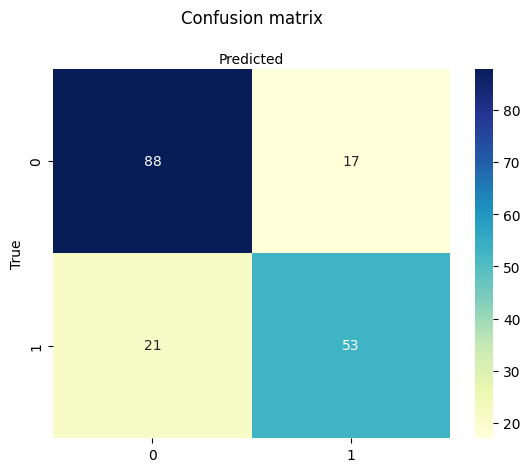

In [34]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [35]:
from sklearn.naive_bayes import GaussianNB

In [36]:
gaussian = GaussianNB()


In [37]:
scores = cross_val_score(gaussian, X, y, cv=4) # K = 4
scores

array([0.69058296, 0.78475336, 0.73542601, 0.80630631])

In [38]:
gaussian.fit(X_train, y_train)
y_pred = gaussian.predict(X_test)

acc_gaussian = metrics.accuracy_score(y_test, y_pred)
pre_gaussian = metrics.precision_score(y_test, y_pred)
rec_gaussian = metrics.recall_score(y_test, y_pred)
f1_gaussian = f1_score(y_test, y_pred, average='micro')
cohen_gaussian = cohen_kappa_score(y_test, y_pred)

In [39]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.7430167597765364
Precision: 0.71875
Recall: 0.6216216216216216


Text(0.5, 23.52222222222222, 'Predicted')

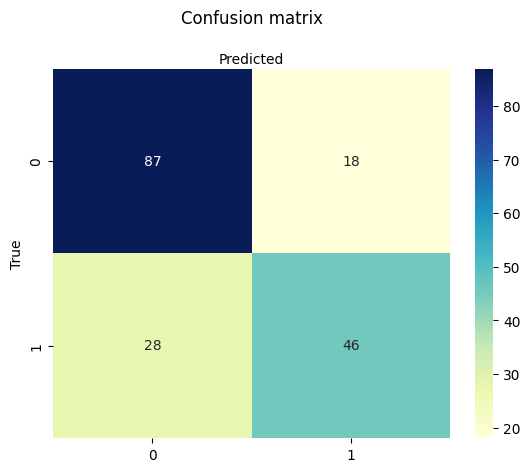

In [40]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [41]:
from sklearn.tree import DecisionTreeClassifier


In [42]:
decision_tree = DecisionTreeClassifier()


In [43]:
scores = cross_val_score(decision_tree, X, y, cv=4) # K = 4
scores


array([0.70403587, 0.79820628, 0.75336323, 0.78828829])

In [44]:
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)

acc_decision = metrics.accuracy_score(y_test, y_pred)
pre_decision = metrics.precision_score(y_test, y_pred)
rec_decision = metrics.recall_score(y_test, y_pred)
f1_decision = f1_score(y_test, y_pred, average='micro')
cohen_decision = cohen_kappa_score(y_test, y_pred)

In [45]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.770949720670391
Precision: 0.6987951807228916
Recall: 0.7837837837837838


Text(0.5, 23.52222222222222, 'Predicted')

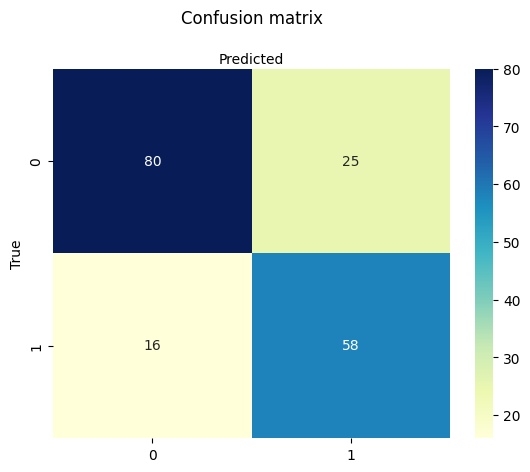

In [46]:

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [47]:
from sklearn.linear_model import Perceptron


In [48]:
per = Perceptron(tol=1e-3, random_state=0)


In [49]:
scores = cross_val_score(per, X, y, cv=4) # K = 4
scores


array([0.44843049, 0.65919283, 0.61883408, 0.38288288])

In [50]:
per.fit(X_train, y_train)
y_pred = per.predict(X_test)

acc_per = metrics.accuracy_score(y_test, y_pred)
pre_per = metrics.precision_score(y_test, y_pred)
rec_per = metrics.recall_score(y_test, y_pred)
f1_per = f1_score(y_test, y_pred, average='micro')
cohen_per = cohen_kappa_score(y_test, y_pred)

In [51]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))


Accuracy: 0.5921787709497207
Precision: 1.0
Recall: 0.013513513513513514


Text(0.5, 23.52222222222222, 'Predicted')

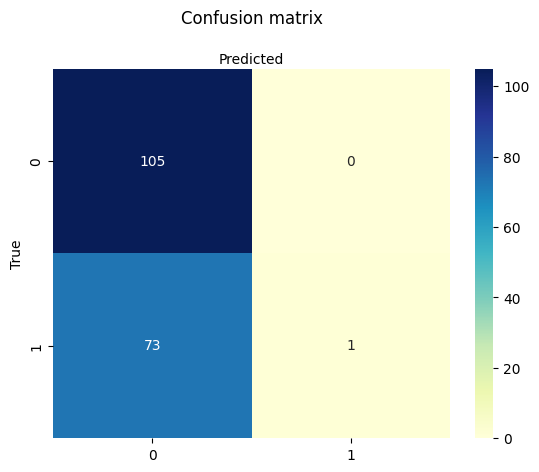

In [52]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [53]:
from sklearn.ensemble import RandomForestClassifier


In [54]:
rf = RandomForestClassifier(max_depth=2, random_state=0)


In [55]:
scores = cross_val_score(rf, X, y, cv=4) # K = 4
scores


array([0.79372197, 0.8206278 , 0.78923767, 0.77477477])

In [56]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc_rf = metrics.accuracy_score(y_test, y_pred)
pre_rf = metrics.precision_score(y_test, y_pred)
rec_rf = metrics.recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred, average='micro')
cohen_rf = cohen_kappa_score(y_test, y_pred)

In [57]:

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))


Accuracy: 0.7821229050279329
Precision: 0.7777777777777778
Recall: 0.6621621621621622


Text(0.5, 23.52222222222222, 'Predicted')

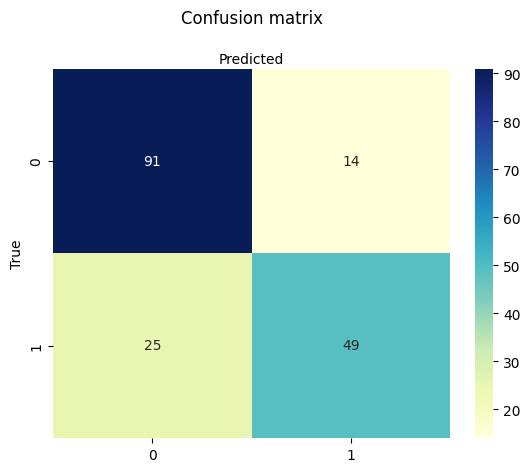

In [58]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [59]:
from sklearn.linear_model import SGDClassifier


In [60]:
SGD = SGDClassifier(loss="log_loss", penalty="l1", max_iter=5) # Changed 'log' to 'log_loss'


In [61]:
scores = cross_val_score(SGD, X, y, cv=4) # K = 4
scores

array([0.53363229, 0.7309417 , 0.78026906, 0.73873874])

In [62]:
SGD.fit(X_train, y_train)
y_pred = SGD.predict(X_test)

acc_SGD = metrics.accuracy_score(y_test, y_pred)
pre_SGD = metrics.precision_score(y_test, y_pred)
rec_SGD = metrics.recall_score(y_test, y_pred)
f1_SGD = f1_score(y_test, y_pred, average='micro')
cohen_SGD = cohen_kappa_score(y_test, y_pred)

In [63]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.7262569832402235
Precision: 0.6126126126126126
Recall: 0.918918918918919


Text(0.5, 23.52222222222222, 'Predicted')

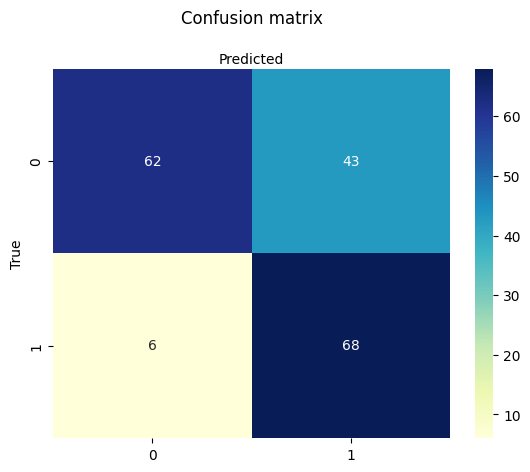

In [64]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [65]:
from sklearn.ensemble import AdaBoostClassifier


In [66]:
AdB = AdaBoostClassifier(n_estimators=100)


In [67]:
scores = cross_val_score(AdB, X, y, cv=4) # K = 4
scores


array([0.76681614, 0.84304933, 0.80269058, 0.81981982])

In [68]:
AdB.fit(X_train, y_train)
y_pred = SGD.predict(X_test)

acc_AdB = metrics.accuracy_score(y_test, y_pred)
pre_AdB = metrics.precision_score(y_test, y_pred)
rec_AdB = metrics.recall_score(y_test, y_pred)
f1_AdB = f1_score(y_test, y_pred, average='micro')
cohen_AdB = cohen_kappa_score(y_test, y_pred)

In [69]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.7262569832402235
Precision: 0.6126126126126126
Recall: 0.918918918918919


Text(0.5, 23.52222222222222, 'Predicted')

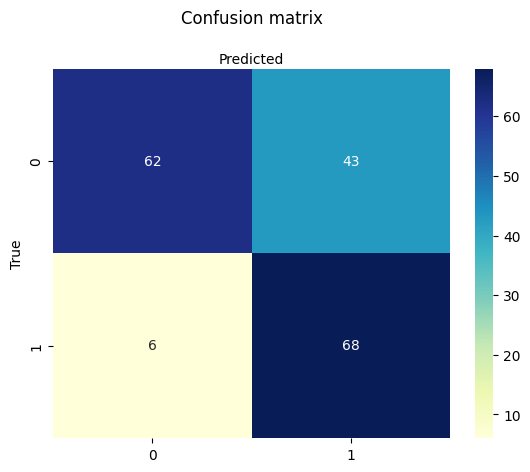

In [70]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [71]:
from sklearn.neural_network import MLPClassifier


In [72]:
mlp = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(25, 15), random_state=1)


In [73]:
scores = cross_val_score(mlp, X, y, cv=4) # K = 4
scores


array([0.74887892, 0.80269058, 0.76681614, 0.7972973 ])

In [74]:
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

acc_mlp = metrics.accuracy_score(y_test, y_pred)
pre_mlp = metrics.precision_score(y_test, y_pred)
rec_mlp = metrics.recall_score(y_test, y_pred)
f1_mlp = f1_score(y_test, y_pred, average='micro')
cohen_mlp = cohen_kappa_score(y_test, y_pred)


In [75]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))


Accuracy: 0.7988826815642458
Precision: 0.7714285714285715
Recall: 0.7297297297297297


Text(0.5, 23.52222222222222, 'Predicted')

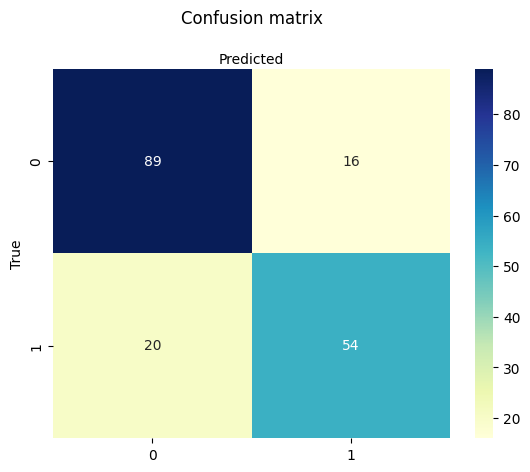

In [76]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

labels = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True')
plt.xlabel('Predicted')

In [77]:
results = pd.DataFrame({
    'Model': ['Support Vector Machines', 'KNN', 'Logistic Regression','Naive Bayes',
              'Decision Tree','Perceptron', 'Random Forest', 'Stochastic Gradient Descent',
              'Ada Boost','Multi Layer perceptron'],

    'Accuracy': [acc_linear_svc, acc_knn, acc_log,
             acc_gaussian, acc_decision,acc_per,acc_rf,acc_SGD,acc_AdB,acc_mlp],

    'Precision': [pre_linear_svc, pre_knn, pre_log,
             pre_gaussian, pre_decision,pre_per,pre_rf,pre_SGD,pre_AdB,pre_mlp],

    'Recall': [rec_linear_svc, rec_knn, rec_log,
             rec_gaussian, rec_decision,rec_per,rec_rf,rec_SGD,rec_AdB,rec_mlp],

    'F1-Score': [f1_linear_svc, f1_knn, f1_log,
         f1_gaussian, f1_decision,f1_per,f1_rf,f1_SGD,f1_AdB,f1_mlp],

    'Cohen Kappa ': [cohen_linear_svc, cohen_knn, cohen_log,
     cohen_gaussian, cohen_decision,cohen_per,cohen_rf,cohen_SGD,cohen_AdB,cohen_mlp]
})

result_df = results.sort_values(by='Accuracy', ascending=False)
result_df = result_df.set_index('Accuracy')
result_df


,Model,Precision,Recall,F1-Score,Cohen Kappa
Accuracy,,,,,
0.810056,Logistic Regression,0.785714,0.743243,0.810056,0.605215
0.798883,Multi Layer perceptron,0.771429,0.729730,0.798883,0.581993
0.787709,Support Vector Machines,0.757143,0.716216,0.787709,0.558770
0.782123,Random Forest,0.777778,0.662162,0.782123,0.540693
0.770950,Decision Tree,0.698795,0.783784,0.770950,0.536064
0.759777,KNN,0.781818,0.581081,0.759777,0.485185
0.743017,Naive Bayes,0.718750,0.621622,0.743017,0.459357
0.726257,Stochastic Gradient Descent,0.612613,0.918919,0.726257,0.474381
0.726257,Ada Boost,0.612613,0.918919,0.726257,0.474381


In [82]:
!pip install -U scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Perceptron
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# Load the data (replace with your data path if needed)
titanic = pd.read_csv("train.csv")

# Preprocessing
embarked_dummies = pd.get_dummies(titanic['Embarked'], prefix='Embarked').astype(int)
titanic = pd.concat([titanic, embarked_dummies], axis=1)
titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis=1, inplace=True)
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1}).astype(int)

# Features and target
X = titanic.drop('Survived', axis=1)
y = titanic['Survived']

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=3)  # You can adjust n_components
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame and add to original DataFrame
pca_columns = [f'PCA_{i+1}' for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)
X = pd.concat([X.reset_index(drop=True), pca_df], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training and Evaluation with Hyperparameter Tuning (if applicable)
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Linear SVC': LinearSVC(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'Perceptron': Perceptron(),
    'Random Forest': RandomForestClassifier(max_depth=5, random_state=0),
    'SGD': SGDClassifier(loss="log_loss"),
    'AdaBoost': AdaBoostClassifier(),
    'MLP': MLPClassifier(max_iter=1000) # Increased max_iter for MLP
}

results = []

for model_name, model in models.items():
    # Hyperparameter tuning can be added here (example for Logistic Regression shown previously)

    # Train and predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cohen_kappa = cohen_kappa_score(y_test, y_pred)

    results.append([model_name, accuracy, precision, recall, f1, cohen_kappa])

# Display results
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Cohen Kappa'])
print(results_df.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy  Precision    Recall  F1-Score  Cohen Kappa
6        Random Forest  0.810056   0.822581  0.689189  0.750000     0.598761
0  Logistic Regression  0.804469   0.774648  0.743243  0.758621     0.594420
9                  MLP  0.804469   0.791045  0.716216  0.751773     0.591138
8             AdaBoost  0.793296   0.746667  0.756757  0.751678     0.574658
3          Naive Bayes  0.787709   0.730769  0.770270  0.750000     0.565756
2           Linear SVC  0.787709   0.757143  0.716216  0.736111     0.558770
4        Decision Tree  0.776536   0.717949  0.756757  0.736842     0.542901
1                  KNN  0.709497   0.683333  0.554054  0.611940     0.383821
5           Perceptron  0.636872   0.536000  0.905405  0.673367     0.320425
7                  SGD  0.597765   1.000000  0.027027  0.052632     0.031560
